# Photolithography Through a Data Scientist's Eyes
## Fourier Optics — From Mask to Wafer in Python

**Author:** Nishant Bhadauria  
**Reference:** Burn Lin — *Optical Lithography: Here is Why*  

This notebook simulates the core Fourier optics pipeline in photolithography:

1. **Mask as a Signal** — represent a grating pattern as a spatial signal
2. **Diffraction = Fourier Transform** — decompose mask into spatial frequencies
3. **Lens as a Filter** — apply NA cutoff in frequency domain
4. **Image Reconstruction** — inverse FFT, show resolution degradation

No special installs needed — pure `numpy` and `matplotlib`.
Runs on Google Colab or any standard Python environment.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Global plot style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.family': 'sans-serif',
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

print('Libraries loaded. Ready to simulate.')

Libraries loaded. Ready to simulate.


---
## Block 1: The Mask as a Signal

A mask is a pattern of lines and spaces — chrome blocking light, quartz transmitting it.  
In signal processing terms, it is a **binary spatial signal** — ones where light passes, zeros where it does not.

We model a simple **diffraction grating**: equally spaced lines and spaces.

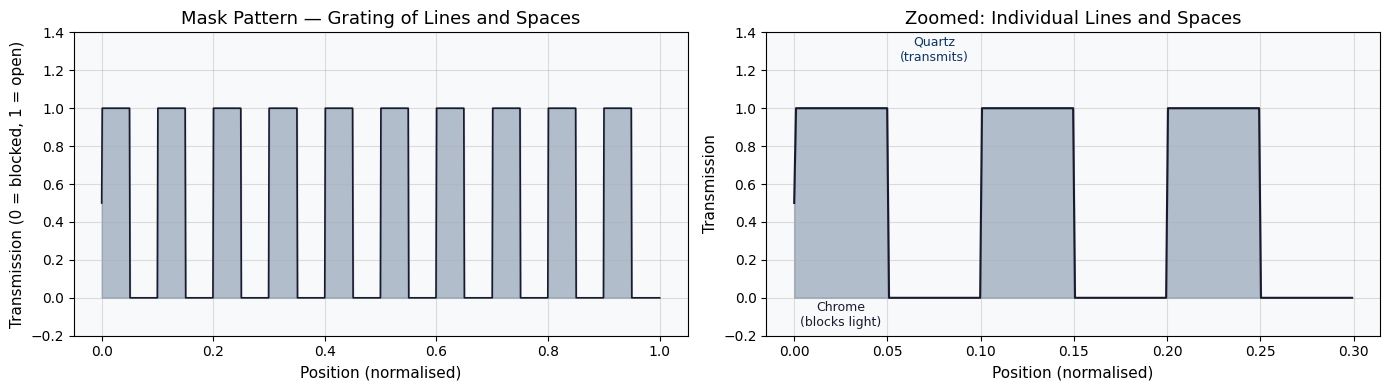

Mask: 10 line pairs, 1024 spatial samples


In [2]:
# ─── BLOCK 1: Mask as a Signal ───────────────────────────────────────────────

N = 1024                          # number of spatial samples
x = np.linspace(0, 1, N)         # normalised spatial coordinate [0, 1]
line_pairs = 10                   # number of line-space pairs across the mask

# Binary grating: 1 where light transmits, 0 where chrome blocks
mask = 0.5 * (1 + np.sign(np.sin(2 * np.pi * line_pairs * x)))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: full mask
axes[0].plot(x, mask, color='#1A1A2E', linewidth=1.2)
axes[0].fill_between(x, 0, mask, alpha=0.3, color='#0F3460')
axes[0].set_title('Mask Pattern — Grating of Lines and Spaces')
axes[0].set_xlabel('Position (normalised)')
axes[0].set_ylabel('Transmission (0 = blocked, 1 = open)')
axes[0].set_ylim(-0.2, 1.4)

# Right: zoomed in to show 3 periods
zoom = x < 0.3
axes[1].plot(x[zoom], mask[zoom], color='#1A1A2E', linewidth=1.5)
axes[1].fill_between(x[zoom], 0, mask[zoom], alpha=0.3, color='#0F3460')
axes[1].set_title('Zoomed: Individual Lines and Spaces')
axes[1].set_xlabel('Position (normalised)')
axes[1].set_ylabel('Transmission')
axes[1].set_ylim(-0.2, 1.4)

# Annotate chrome and quartz regions
axes[1].annotate('Chrome\n(blocks light)', xy=(0.025, 0.0), xytext=(0.025, -0.15),
                 ha='center', fontsize=9, color='#1A1A2E')
axes[1].annotate('Quartz\n(transmits)', xy=(0.075, 1.0), xytext=(0.075, 1.25),
                 ha='center', fontsize=9, color='#0F3460')

plt.tight_layout()
plt.savefig('block1_mask_pattern.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Mask: {line_pairs} line pairs, {N} spatial samples')

---
## Block 2: Diffraction = Fourier Transform

When light hits the mask, it diffracts. Physically, diffraction **decomposes the mask pattern into spatial frequencies** — this is the Fourier transform, performed by light itself.

- **Low spatial frequencies** → coarse features, small diffraction angles  
- **High spatial frequencies** → fine features, large diffraction angles  

We compute the FFT of the mask and visualise the frequency spectrum — the **diffraction pattern at the lens pupil plane**.

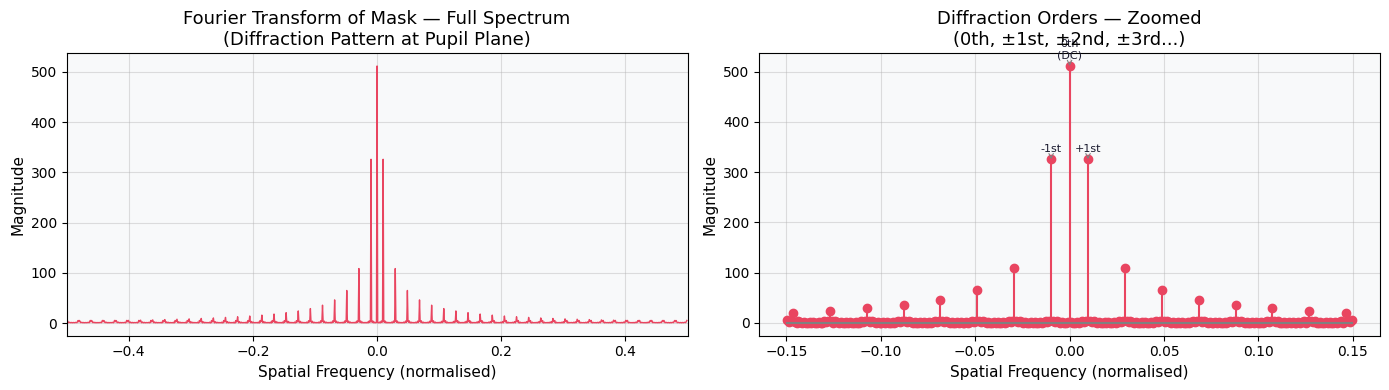

Each spike = one diffraction order. The lens will decide which ones survive.


In [3]:
# ─── BLOCK 2: Diffraction = Fourier Transform ────────────────────────────────

# FFT of the mask — this is what light does physically via diffraction
mask_fft = np.fft.fftshift(np.fft.fft(mask))
freqs = np.fft.fftshift(np.fft.fftfreq(N))  # normalised spatial frequencies
magnitude = np.abs(mask_fft)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: full spectrum
axes[0].plot(freqs, magnitude, color='#E94560', linewidth=1.0)
axes[0].set_title('Fourier Transform of Mask — Full Spectrum\n(Diffraction Pattern at Pupil Plane)')
axes[0].set_xlabel('Spatial Frequency (normalised)')
axes[0].set_ylabel('Magnitude')
axes[0].set_xlim(-0.5, 0.5)

# Right: zoomed to show diffraction orders clearly
zoom_freq = np.abs(freqs) < 0.15
axes[1].stem(freqs[zoom_freq], magnitude[zoom_freq],
             linefmt='#E94560', markerfmt='o', basefmt='gray')
axes[1].set_title('Diffraction Orders — Zoomed\n(0th, ±1st, ±2nd, ±3rd...)')
axes[1].set_xlabel('Spatial Frequency (normalised)')
axes[1].set_ylabel('Magnitude')

# Annotate key orders
order_freqs = [0, line_pairs/N, -line_pairs/N, 2*line_pairs/N, -2*line_pairs/N]
order_labels = ['0th\n(DC)', '+1st', '-1st', '+2nd', '-2nd']
for f, label in zip(order_freqs, order_labels):
    idx = np.argmin(np.abs(freqs - f))
    if magnitude[idx] > 5:
        axes[1].annotate(label, xy=(freqs[idx], magnitude[idx]),
                         xytext=(freqs[idx], magnitude[idx] + 15),
                         ha='center', fontsize=8, color='#1A1A2E',
                         arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))

plt.tight_layout()
plt.savefig('block2_diffraction_fft.png', dpi=150, bbox_inches='tight')
plt.show()
print('Each spike = one diffraction order. The lens will decide which ones survive.')

---
## Block 3: Lens as a Low-Pass Filter — NA Cutoff

The lens aperture sits at the pupil plane (the Fourier plane).  
It physically blocks diffraction orders beyond the **NA cutoff frequency**:

$$f_{cutoff} = \frac{NA}{\lambda}$$

We simulate three NA values and show which frequencies survive in each case.

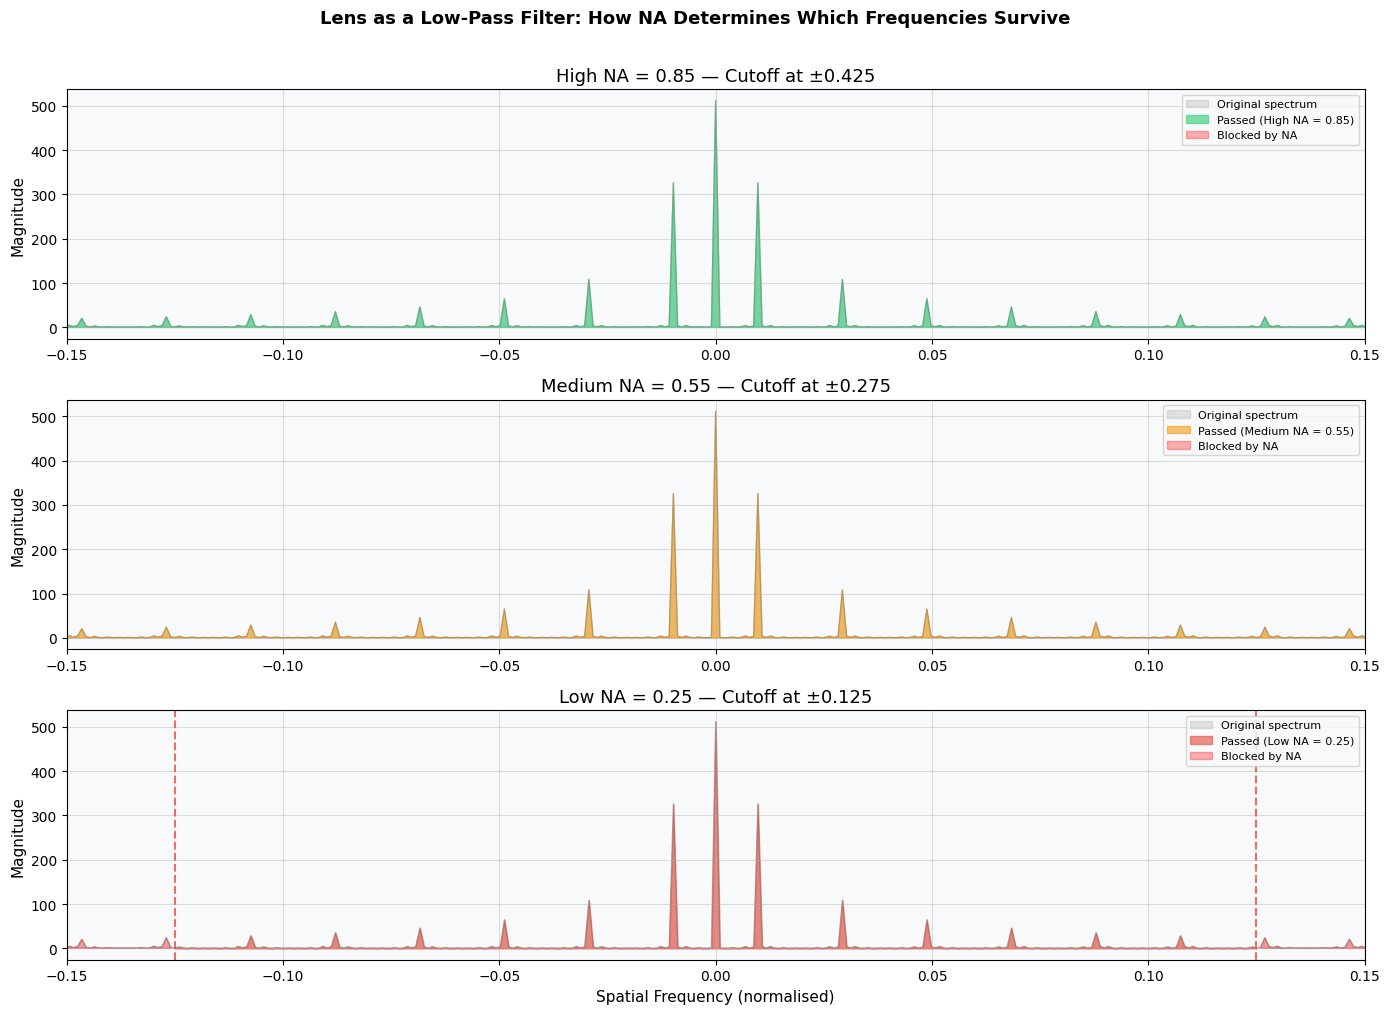

Red regions = information lost forever. Cannot be recovered in the image.


In [4]:
# ─── BLOCK 3: Lens as a Low-Pass Filter ──────────────────────────────────────

wavelength = 193e-9   # 193nm ArF laser (normalised scale)

# NA values to compare
na_values = [0.85, 0.55, 0.25]
na_colors = ['#2ecc71', '#f39c12', '#e74c3c']
na_labels = ['High NA = 0.85', 'Medium NA = 0.55', 'Low NA = 0.25']

# Normalised cutoff: fraction of total frequency range
# For a grating with 10 line pairs in N=1024 samples,
# fundamental frequency is at 10/1024 in normalised units
# We define NA cutoff relative to the grating fundamental
f_fundamental = line_pairs / N

def na_cutoff(na):
    """Returns normalised cutoff frequency scaled to our simulation."""
    return na * 0.5  # NA=1.0 passes half the spectrum

def apply_na_filter(fft_signal, freqs, na):
    """Zero out frequencies beyond NA cutoff — the lens pupil function."""
    cutoff = na_cutoff(na)
    pupil = (np.abs(freqs) <= cutoff).astype(float)
    return fft_signal * pupil, pupil

fig, axes = plt.subplots(3, 1, figsize=(14, 10))

filtered_ffts = {}

for i, (na, color, label) in enumerate(zip(na_values, na_colors, na_labels)):
    filtered_fft, pupil = apply_na_filter(mask_fft, freqs, na)
    filtered_ffts[na] = filtered_fft

    axes[i].fill_between(freqs, 0, magnitude, alpha=0.2, color='gray', label='Original spectrum')
    axes[i].plot(freqs, magnitude, color='gray', linewidth=0.8, alpha=0.5)
    axes[i].fill_between(freqs, 0, np.abs(filtered_fft),
                         where=pupil > 0, alpha=0.6, color=color, label=f'Passed ({label})')
    axes[i].fill_between(freqs, 0, magnitude,
                         where=pupil == 0, alpha=0.3, color='red', label='Blocked by NA')

    cutoff = na_cutoff(na)
    axes[i].axvline(cutoff, color=color, linestyle='--', linewidth=1.5, alpha=0.8)
    axes[i].axvline(-cutoff, color=color, linestyle='--', linewidth=1.5, alpha=0.8)
    axes[i].set_xlim(-0.15, 0.15)
    axes[i].set_title(f'{label} — Cutoff at ±{cutoff:.3f}')
    axes[i].set_ylabel('Magnitude')
    axes[i].legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Spatial Frequency (normalised)')
plt.suptitle('Lens as a Low-Pass Filter: How NA Determines Which Frequencies Survive',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('block3_na_filter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Red regions = information lost forever. Cannot be recovered in the image.')

---
## Block 4: Image Reconstruction — Inverse FFT

The lens recombines the surviving frequency components onto the wafer.  
Mathematically this is the **inverse Fourier transform** of the filtered spectrum.

We compare the reconstructed image for each NA value against the original mask.  
Watch how the image degrades as NA shrinks — fewer frequencies, blurrier edges, lower contrast.

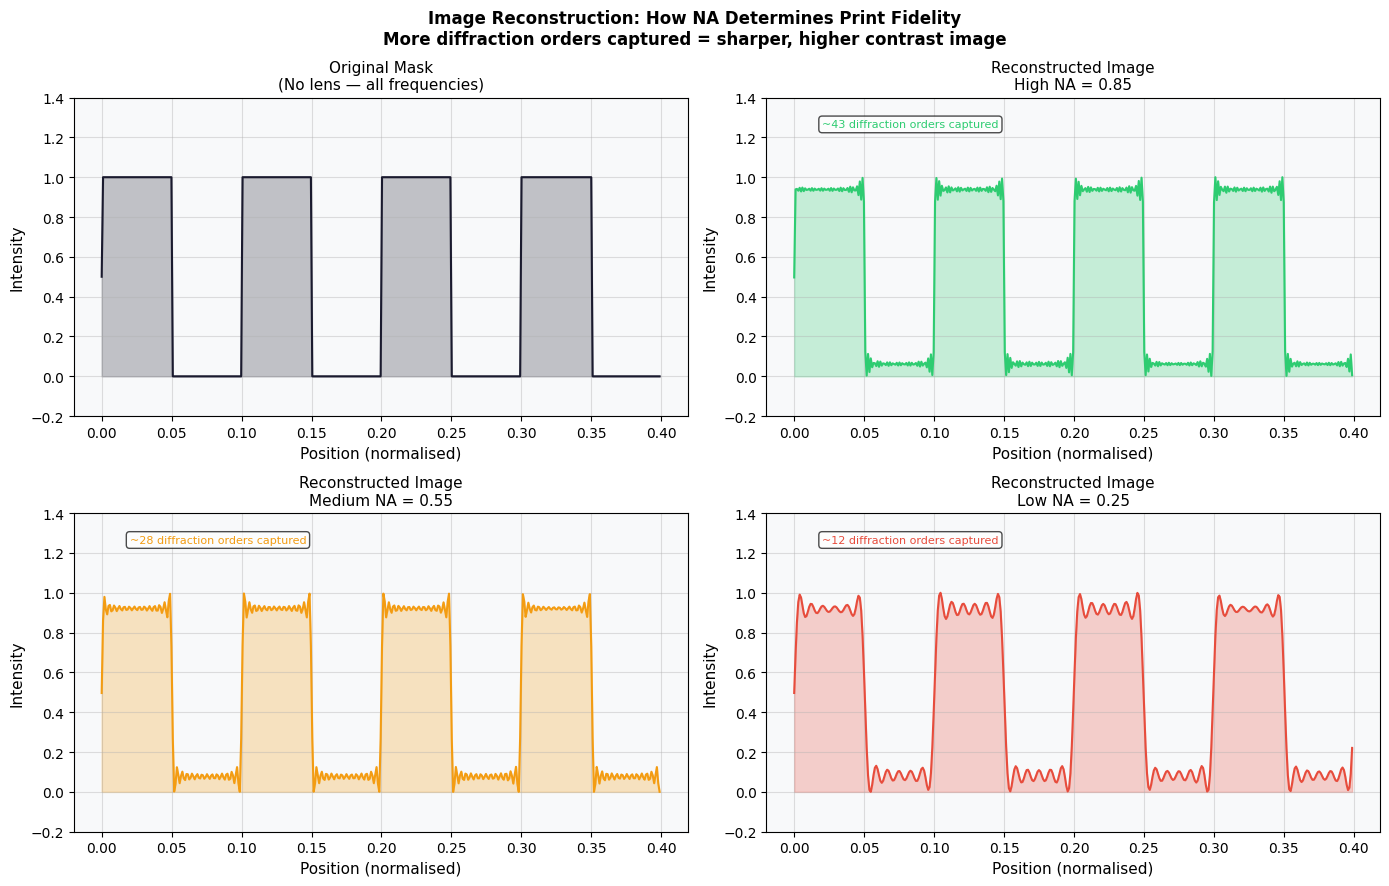

This is the core of photolithography imaging — a Fourier optics pipeline.


In [5]:
# ─── BLOCK 4: Image Reconstruction — Inverse FFT ─────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

all_cases = [(None, 'Original Mask\n(No lens — all frequencies)', '#1A1A2E')] + \
            list(zip(na_values, na_labels, na_colors))

for i, case in enumerate(all_cases):
    if case[0] is None:
        # Original mask
        signal = mask
        title = case[1]
        color = case[2]
    else:
        na, label, color = case
        # Inverse FFT of filtered spectrum
        filtered = filtered_ffts[na]
        reconstructed = np.real(np.fft.ifft(np.fft.ifftshift(filtered)))
        # Normalise to [0,1]
        reconstructed = (reconstructed - reconstructed.min())
        reconstructed = reconstructed / reconstructed.max()
        signal = reconstructed
        title = f'Reconstructed Image\n{label}'

    # Show only first 40% of spatial extent for clarity
    show = int(0.4 * N)
    axes[i].plot(x[:show], signal[:show], color=color, linewidth=1.5)
    axes[i].fill_between(x[:show], 0, signal[:show], alpha=0.25, color=color)
    axes[i].set_title(title, fontsize=11)
    axes[i].set_xlabel('Position (normalised)')
    axes[i].set_ylabel('Intensity')
    axes[i].set_ylim(-0.2, 1.4)

    # Add resolution quality annotation
    if case[0] is not None:
        na = case[0]
        # Count how many orders survive
        cutoff = na_cutoff(na)
        orders_passed = int(cutoff / f_fundamental)
        axes[i].text(0.02, 1.25, f'~{orders_passed} diffraction orders captured',
                     fontsize=8, color=color,
                     bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.suptitle('Image Reconstruction: How NA Determines Print Fidelity\n'
             'More diffraction orders captured = sharper, higher contrast image',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('block4_reconstruction.png', dpi=150, bbox_inches='tight')
plt.show()
print('This is the core of photolithography imaging — a Fourier optics pipeline.')

---
## Block 5: The Resolution Limit — Rayleigh Criterion Visualised

We now vary NA continuously and measure image contrast to show the resolution limit emerging naturally from the simulation.

$$R = 0.61 \times \frac{\lambda}{NA}$$

As NA drops, contrast drops. Below a critical NA, the pattern becomes unresolvable.

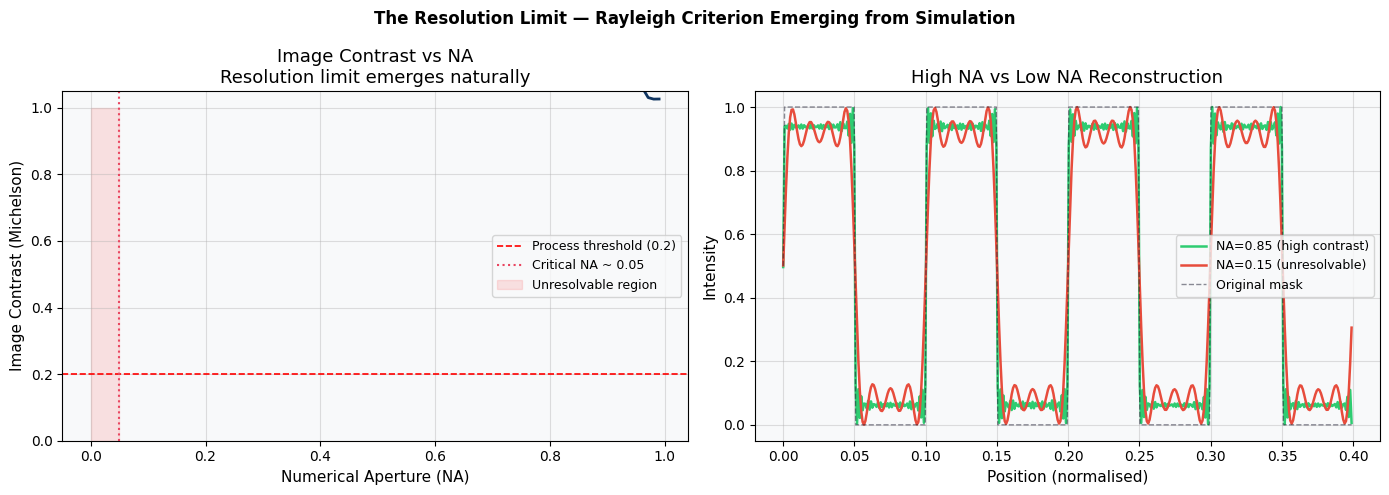

Critical NA for this grating: ~0.05
Below this NA, the pattern cannot be resolved — the resist sees no contrast.


In [6]:
# ─── BLOCK 5: Resolution Limit Visualised ────────────────────────────────────

na_range = np.linspace(0.05, 0.99, 100)
contrasts = []

for na in na_range:
    filtered_fft, _ = apply_na_filter(mask_fft, freqs, na)
    recon = np.real(np.fft.ifft(np.fft.ifftshift(filtered_fft)))
    # Michelson contrast = (Imax - Imin) / (Imax + Imin)
    imax, imin = recon.max(), recon.min()
    contrast = (imax - imin) / (imax + imin) if (imax + imin) > 0 else 0
    contrasts.append(contrast)

contrasts = np.array(contrasts)

# Critical NA — where contrast drops below 0.2 (common process threshold)
threshold = 0.2
critical_na_idx = np.where(contrasts > threshold)[0]
critical_na = na_range[critical_na_idx[0]] if len(critical_na_idx) > 0 else None

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: contrast vs NA curve
axes[0].plot(na_range, contrasts, color='#0F3460', linewidth=2)
axes[0].axhline(threshold, color='red', linestyle='--', linewidth=1.2, label=f'Process threshold ({threshold})')
if critical_na:
    axes[0].axvline(critical_na, color='#E94560', linestyle=':', linewidth=1.5,
                    label=f'Critical NA ~ {critical_na:.2f}')
    axes[0].fill_betweenx([0, 1], 0, critical_na, alpha=0.1, color='red', label='Unresolvable region')
axes[0].set_xlabel('Numerical Aperture (NA)')
axes[0].set_ylabel('Image Contrast (Michelson)')
axes[0].set_title('Image Contrast vs NA\nResolution limit emerges naturally')
axes[0].set_ylim(0, 1.05)
axes[0].legend(fontsize=9)

# Right: show best vs worst reconstruction
na_best, na_worst = 0.85, 0.15
show = int(0.4 * N)

for na, color, label in [(na_best, '#2ecc71', f'NA={na_best} (high contrast)'),
                          (na_worst, '#e74c3c', f'NA={na_worst} (unresolvable)')]:
    filtered_fft, _ = apply_na_filter(mask_fft, freqs, na)
    recon = np.real(np.fft.ifft(np.fft.ifftshift(filtered_fft)))
    recon = (recon - recon.min()) / (recon.max() - recon.min())
    axes[1].plot(x[:show], recon[:show], color=color, linewidth=1.8, label=label)

axes[1].plot(x[:show], mask[:show], color='#1A1A2E', linewidth=1.0,
             linestyle='--', alpha=0.5, label='Original mask')
axes[1].set_xlabel('Position (normalised)')
axes[1].set_ylabel('Intensity')
axes[1].set_title('High NA vs Low NA Reconstruction')
axes[1].legend(fontsize=9)

plt.suptitle('The Resolution Limit — Rayleigh Criterion Emerging from Simulation',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('block5_resolution_limit.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Critical NA for this grating: ~{critical_na:.2f}')
print('Below this NA, the pattern cannot be resolved — the resist sees no contrast.')

---
## Summary

What we simulated:

| Step | Physics | Math | Code |
|------|---------|------|------|
| Mask pattern | Chrome/quartz grating | Binary spatial signal f(x) | `np.sign(np.sin(...))` |
| Diffraction | Light fans out at angles | Fourier Transform F(u) | `np.fft.fft()` |
| Lens aperture | NA blocks high angles | Low-pass filter H(u) | `abs(freqs) <= cutoff` |
| Image formation | Waves recombine on wafer | Inverse Fourier Transform | `np.fft.ifft()` |
| Resolution limit | Contrast collapses | Rayleigh criterion | Michelson contrast curve |

---

### What Comes Next — OPC and ILT

The simulation above models the **forward problem**: given a mask, what image appears on the wafer?

**OPC (Optical Proximity Correction)** solves the **inverse problem**: given a desired wafer image, how do we modify the mask so the forward pipeline produces the correct result?

**ILT (Inverse Lithography Technology)** uses gradient descent through the entire Fourier optics pipeline to compute the theoretically optimal mask.

**ML-based OPC** trains neural networks to approximate this expensive computation — predicting mask corrections in milliseconds rather than hours.

This is where data science meets semiconductor manufacturing.

---

### References
- Burn Lin, *Optical Lithography: Here is Why*, SPIE Press
- Joseph Goodman, *Introduction to Fourier Optics*, Roberts & Company
- ASML: https://www.asml.com/en/technology/lithography-explained
- Micron Educator Hub: https://www.micron.com/education/micron-educator-hub